# 📘 Introduction

## 📌 Background

With the rapid growth of social media platforms, large volumes of user-generated text data are produced every day. Platforms like Twitter contain valuable information reflecting public opinions, emotions, and attitudes toward various topics. Extracting meaningful insights from such data has become an important task in the field of **Natural Language Processing (NLP)**.

**Sentiment Analysis** is a key NLP application that focuses on identifying and classifying the emotional tone of text into categories such as positive, negative, or neutral. It is widely used in areas like product reviews, social media monitoring, customer feedback analysis, and decision-making systems.

---

## 🎯 Objective

The primary objective of this project is to:

- Perform **sentiment classification** on Twitter data  
- Compare the effectiveness of different **NLP preprocessing techniques**  
- Analyze how preprocessing impacts model performance  

Specifically, this study evaluates whether techniques such as **slang normalization** and **emoji normalization** improve classification results.

---

## 🧪 Problem Statement

While preprocessing is often considered an essential step in NLP pipelines, its actual impact on model performance can vary depending on the dataset, feature representation, and model used.

This project addresses the following question:

> *Do preprocessing techniques like slang and emoji normalization significantly improve sentiment classification performance?*

---

## ⚙️ Approach Overview

To answer this question, the following approach is adopted:

- Use the **Sentiment140 dataset** for large-scale sentiment analysis  
- Convert the original labels into **binary classes (positive and negative)**  
- Apply multiple preprocessing strategies:
  - Raw (uncleaned) text  
  - Slang-normalized text  
  - Emoji-normalized text  
  - Combined slang + emoji normalization  
- Transform text using **TF-IDF vectorization**  
- Train and evaluate a **Logistic Regression model** on each variant  
- Compare performance using standard evaluation metrics  

---

## 📊 Scope of Study

This project focuses on:

- Evaluating preprocessing impact in a **classical machine learning setup**  
- Using **bag-of-words (TF-IDF)** representation  
- Analyzing results using quantitative metrics and visualizations  

Deep learning approaches are not included in this study but are considered for future work.

---

## 🧠 Significance

Understanding the real impact of preprocessing techniques is important because:

- It helps avoid **unnecessary complexity** in NLP pipelines  
- It provides insight into **model behavior and feature importance**  
- It guides the selection of **efficient and effective preprocessing strategies**  

This study aims to provide a practical and evidence-based understanding of preprocessing in sentiment analysis tasks.

In [ ]:
import pandas as pd
import numpy as np
import re

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
! pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing twitter sentiment dataset

In [ ]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 221MB/s]



In [ ]:
# extracting the compressed dataset

from zipfile import ZipFile
dataset = '/content/sentiment140.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted successfully')

The dataset is extracted successfully


In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
# loading the data from the csv file to pandas dataframe
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding = 'ISO-8859-1', on_bad_lines='skip')

In [ ]:
# checking the number of rows and columns
twitter_data.shape


(1599999, 6)

In [ ]:
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
twitter_data.tail()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1599994,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...
1599998,4,2193602129,Tue Jun 16 08:40:50 PDT 2009,NO_QUERY,RyanTrevMorris,happy #charitytuesday @theNSPCC @SparksCharity...


In [ ]:
# naiming the columns and reading the dataset again
column_names = ['target', 'ids', 'data', 'flag', 'user', 'text']
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', names = column_names , encoding = 'ISO-8859-1')

In [ ]:
twitter_data.columns

Index(['target', 'ids', 'data', 'flag', 'user', 'text'], dtype='object')

In [ ]:
twitter_data.head()

,target,ids,data,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
#counting the numbers of the missing values in the dataframe
twitter_data.isnull().sum()

,0
target,0
ids,0
data,0
flag,0
user,0
text,0


In [ ]:
# checking the distribution of the target column
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


In [ ]:
# convert the targer 4 to 1
twitter_data.replace({'target': {4:1}}, inplace = True)

In [ ]:
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


0 --> Negative Tweet \
1 --> Positive Tweet

**Slang normalization**

In [ ]:
slang_dict = {
    # Positive slang
    "lit": "good",
    "fire": "excellent",
    "dope": "great",
    "goated": "great",
    "awesome": "great",
    "cool": "good",
    "nice": "good",
    "amazing": "great",
    "love": "great",
    "luv": "love",
    "gr8": "great",
    "banger": "excellent",
    "slaps": "excellent",
    "hits": "good",
    "solid": "good",

    # Negative slang
    "trash": "bad",
    "garbage": "bad",
    "mid": "average",
    "meh": "average",
    "lame": "bad",
    "worst": "bad",
    "awful": "bad",
    "terrible": "bad",
    "sucks": "bad",
    "suck": "bad",
    "wtf": "bad",
    "ugh": "bad",

    # Neutral / context slang
    "ok": "average",
    "okay": "average",

    # Internet slang / abbreviations
    "lol": "funny",
    "lmao": "funny",
    "rofl": "funny",
    "omg": "surprised",
    "idk": "unknown",
    "imo": "opinion",
    "imho": "opinion",
    "btw": "by the way",
    "tbh": "honest",

    # Negative expressions
    "smh": "disappointed",
    "bruh": "annoyed",
    "facepalm": "disappointed",

    # Positive expressions
    "yass": "yes",
    "yaaas": "yes",
    "yesss": "yes",

    # Suspicion / doubt
    "sus": "suspicious",
    "sketchy": "suspicious",

    # Gen-Z / modern slang
    "no cap": "true",
    "cap": "lie",
    "based": "good",
    "cringe": "bad",
    "vibe": "feeling",
    "vibes": "feeling",
    "lowkey": "slightly",
    "highkey": "very",

    # Intensifiers
    "super": "very",
    "hella": "very",
    "mad": "very",

    # Short forms
    "u": "you",
    "ur": "your",
    "r": "are",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
    "ty": "thanks"
}

def normalize_slang(text):
    text = text.lower()

    # multi-word slang
    for key, value in slang_dict.items():
        if " " in key:
            pattern = r'\b' + re.escape(key) + r'\b'
            text = re.sub(pattern, value, text)

    # single-word slang
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]

    return " ".join(words)

Testing Slang Normalization

In [ ]:
texts = [
    "This product is fire 🔥",
    "This is no cap amazing",
    "Bruh this is trash 😡",
    "Kinda mid but ok",
]

for t in texts:
    print("Original:", t)
    print("Processed:", normalize_slang(t))
    print("-" * 40)

Original: This product is fire 🔥
Processed: this product is excellent 🔥
----------------------------------------
Original: This is no cap amazing
Processed: this is true great
----------------------------------------
Original: Bruh this is trash 😡
Processed: annoyed this is bad 😡
----------------------------------------
Original: Kinda mid but ok
Processed: kinda average but average
----------------------------------------


In [ ]:
!pip install swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=5e77baca8f3c375e649998298a526c4958ed453e2f9cf4881278b63aeb64f379
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter


swifter is a library that makes .apply() on Pandas faster automatically.

It does this by:

- checking your data size
- choosing the best execution method (normal / vectorized / parallel)

In [ ]:
import swifter

Applying slang normalization on the dataset

In [ ]:
twitter_data['clean_text'] = twitter_data['text'].swifter.apply(normalize_slang)

Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

**Emojies Normalization**

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.9 MB/s eta 0:00:00


In [ ]:
import emoji
import re

# Step 1: convert emoji → text
def replace_emojis(text):
    text = emoji.demojize(text, delimiters=(" ", " "))

    # clean formatting
    text = re.sub(r':', '', text)
    text = text.replace("_", " ")

    return text

emoji_sentiment_map = {
    "smiling face with heart-eyes": "love",
    "heart eyes": "love",
    "fire": "excellent",
    "kissing face": "love",
    "kissing face with closed eyes": "love",
    "kissing face with smiling eyes": "love",
    "thumbs up": "good",
    "smiling face": "happy",
    "grinning face with smiling eyes": "happy",
    "grinning face": "happy",

    "angry face": "angry",
    "pouting face": "angry",
    "loudly crying face": "sad",
    "crying face": "sad",

    "broken heart": "sad",
    "enraged face": "angry",
    "crying face with open mouth": "sad",

    "neutral face": "neutral",
    "thinking face": "thinking",

}

In [ ]:
def simplify_emojis(text):
    for key, value in emoji_sentiment_map.items():
        pattern = r'\b' + re.escape(key) + r'\b'
        text = re.sub(pattern, value, text)

    return text

In [ ]:
def process_emojis(text):
    text = replace_emojis(text)
    text = simplify_emojis(text)
    return text

In [ ]:
### Testing the emoji conversion
test_texts = [
    "This is amazing 🔥😍",
    "Worst experience ever 😡",
    "I feel so sad 😭💔",
    "Okay product 👍",
    "Hmm... not sure 🤔"
]

for t in test_texts:
    print("Original:", t)
    print("Processed:", process_emojis(t))
    print("-" * 40)

Original: This is amazing 🔥😍
Processed: This is amazing  excellent  love 
----------------------------------------
Original: Worst experience ever 😡
Processed: Worst experience ever  angry 
----------------------------------------
Original: I feel so sad 😭💔
Processed: I feel so sad  sad  sad 
----------------------------------------
Original: Okay product 👍
Processed: Okay product  good 
----------------------------------------
Original: Hmm... not sure 🤔
Processed: Hmm... not sure  thinking 
----------------------------------------


In [ ]:
### Applying emojis normalization on the dataset
twitter_data["emoji_processed"] = twitter_data["text"].swifter.apply(process_emojis)

Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

In [ ]:
### Applying emojis normalization on the slang normailzed dataset
twitter_data["emoji_slang_processed"] = twitter_data["clean_text"].swifter.apply(process_emojis)

Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

**Now the data are stored in 4 columns**
- text
- clean_text --> slang
- emoji_processed  --> emojis
- emoji_slang_processed  --> emojis and slangs

so that results of multiple cleaning steps can be compared

**steaming**

Reducing the words to its root words \
eg: actor, actress, acting --> act

In [ ]:
port_stem = PorterStemmer()

In [ ]:
stop_words = set(stopwords.words('english'))

def stemming(content):
  stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
  stemmed_content = stemmed_content.lower()
  stemmed_content = stemmed_content.split()
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stop_words]

  return ' '.join(stemmed_content)

Applying stemming in the text field of the dataset

In [ ]:
# for raw texts
twitter_data['stemmed_content'] = twitter_data['text'].swifter.apply(stemming)

Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

In [ ]:
# slangs normalized texts
twitter_data['stemmed_clean_text'] = twitter_data['clean_text'].swifter.apply(stemming)

# emojis normalized
twitter_data['stemmed_emoji_processed'] = twitter_data['emoji_processed'].swifter.apply(stemming)

# enojis and text normalized
twitter_data['stemmed_emoji_slang_processed'] = twitter_data['emoji_slang_processed'].swifter.apply(stemming)


Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/1600000 [00:00<?, ?it/s]

In [ ]:
twitter_data.head()

,target,ids,data,flag,user,text,clean_text,emoji_processed,emoji_slang_processed,stemmed_content,stemmed_clean_text,stemmed_emoji_processed,stemmed_emoji_slang_processed
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...","@switchfoot http://twitpic.com/2y1zl - awww, t...","@switchfoot http//twitpic.com/2y1zl - Awww, th...","@switchfoot http//twitpic.com/2y1zl - awww, th...",switchfoot http twitpic com zl awww bummer sho...,switchfoot http twitpic com zl awww bummer sho...,switchfoot http twitpic com zl awww bummer sho...,switchfoot http twitpic com zl awww bummer sho...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...,upset updat facebook text might cri result sch...,upset updat facebook text might cri result sch...,upset updat facebook text might cri result sch...,upset updat facebook text might cri result sch...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,@kenichan i dived many times for the ball. man...,@Kenichan I dived many times for the ball. Man...,@kenichan i dived many times for the ball. man...,kenichan dive mani time ball manag save rest g...,kenichan dive mani time ball manag save rest g...,kenichan dive mani time ball manag save rest g...,kenichan dive mani time ball manag save rest g...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on exce...,my whole body feels itchy and like its on exce...,my whole body feels itchy and like its on exce...,whole bodi feel itchi like fire,whole bodi feel itchi like excel,whole bodi feel itchi like excel,whole bodi feel itchi like excel
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....","@nationwideclass no, it's not behaving at all....","@nationwideclass no, it's not behaving at all....","@nationwideclass no, it's not behaving at all....",nationwideclass behav mad see,nationwideclass behav mad see,nationwideclass behav mad see,nationwideclass behav mad see


In [ ]:
print(twitter_data['stemmed_content'].head())


0    switchfoot http twitpic com zl awww bummer sho...
1    upset updat facebook text might cri result sch...
2    kenichan dive mani time ball manag save rest g...
3                      whole bodi feel itchi like fire
4                        nationwideclass behav mad see
Name: stemmed_content, dtype: object


In [ ]:
twitter_data.target.head()


,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
# seperating the data and label
#uncleaned
X = twitter_data['stemmed_content'].values

# slang normalized
X_clean = twitter_data['stemmed_clean_text'].values
# Emoji normalized
X_emoji = twitter_data['stemmed_emoji_processed'].values
X_emoji_slang = twitter_data['stemmed_emoji_slang_processed'].values
y = twitter_data['target'].values

In [ ]:
print(X[:5])

['switchfoot http twitpic com zl awww bummer shoulda got david carr third day'
 'upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound'
 'whole bodi feel itchi like fire' 'nationwideclass behav mad see']


In [ ]:
print(y[:5])

[0 0 0 0 0]


Splitting the data to trainin and testing data

In [ ]:
# Split labels (same for all experiments)
y_train, y_test = train_test_split(y, test_size=0.2, stratify=y, random_state=123)

# Split different feature versions
X_train_raw, X_test_raw = train_test_split(X, test_size=0.2, stratify=y, random_state=123)
X_train_clean, X_test_clean = train_test_split(X_clean, test_size=0.2, stratify=y, random_state=123)
X_train_emoji, X_test_emoji = train_test_split(X_emoji, test_size=0.2, stratify=y, random_state=123)
X_train_emoji_slang, X_test_emoji_slang = train_test_split(X_emoji_slang, test_size=0.2, stratify=y, random_state=123)

In [ ]:
print(X.shape, X_train_raw.shape, X_test_raw.shape)

(1600000,) (1280000,) (320000,)


**Feature Extraction**

converting the textual data to numerical data

In [ ]:
# Separate vectorizers for each dataset
vectorizer_raw = TfidfVectorizer()
vectorizer_clean = TfidfVectorizer()
vectorizer_emoji = TfidfVectorizer()
vectorizer_emoji_slang = TfidfVectorizer()

In [ ]:
# Transform text into numerical features
X_train_raw = vectorizer_raw.fit_transform(X_train_raw)
X_test_raw = vectorizer_raw.transform(X_test_raw)

X_train_clean = vectorizer_clean.fit_transform(X_train_clean)
X_test_clean = vectorizer_clean.transform(X_test_clean)

X_train_emoji = vectorizer_emoji.fit_transform(X_train_emoji)
X_test_emoji = vectorizer_emoji.transform(X_test_emoji)

X_train_emoji_slang = vectorizer_emoji_slang.fit_transform(X_train_emoji_slang)
X_test_emoji_slang = vectorizer_emoji_slang.transform(X_test_emoji_slang)

In [ ]:
print(X_train_raw[0], X_test_raw[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (1, 461154)>
  Coords	Values
  (0, 373929)	0.4967210406432779
  (0, 162492)	0.3185049189952804
  (0, 124422)	0.19424818850801515
  (0, 382042)	0.22570979312507747
  (0, 170347)	0.21402004152258616
  (0, 320316)	0.37395113683022646
  (0, 37623)	0.23384956805314747
  (0, 267637)	0.16071085368971813
  (0, 151763)	0.15807380428249504
  (0, 92276)	0.37040787007008386
  (0, 63217)	0.25466788617603264
  (0, 375988)	0.20313957815033132
  (0, 169435)	0.16934339890863384 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16 stored elements and shape (1, 461154)>
  Coords	Values
  (0, 4465)	0.30677067902691446
  (0, 20697)	0.27555525686203425
  (0, 61125)	0.21879984765937224
  (0, 177943)	0.14818856182363127
  (0, 191963)	0.23036156659840099
  (0, 217948)	0.2173649711017105
  (0, 251304)	0.36933206048517797
  (0, 251855)	0.27114655088361184
  (0, 308653)	0.23862958391321099
  (0, 323078)	0.192513

**Training the ML Model**

Logistic Regression

In [ ]:
models = {
    "uncleaned": LogisticRegression(solver='saga', max_iter=1000),
    "slang_cleaned": LogisticRegression(solver='saga', max_iter=1000),
    "emoji_cleaned": LogisticRegression(solver='saga', max_iter=1000),
    "slang_emoji_cleaned": LogisticRegression(solver='saga', max_iter=1000)
}

In [ ]:
X_train_sets = {
    "uncleaned": X_train_raw,
    "slang_cleaned": X_train_clean,
    "emoji_cleaned": X_train_emoji,
    "slang_emoji_cleaned": X_train_emoji_slang
}

X_test_sets = {
    "uncleaned": X_test_raw,
    "slang_cleaned": X_test_clean,
    "emoji_cleaned": X_test_emoji,
    "slang_emoji_cleaned": X_test_emoji_slang
}

# Train and Evaluate models

In [ ]:
results = {}

for name in models:
  model = models[name]

  # train model
  model.fit(X_train_sets[name], y_train)

  # prediction
  train_pred = model.predict(X_train_sets[name])
  test_pred = model.predict(X_test_sets[name])

  # Accuracy score
  train_acc = accuracy_score(y_train, train_pred)
  test_acc = accuracy_score(y_test, test_pred)

  # store results
  results[name] = {
      "train_acc": train_acc,
      "test_acc": test_acc
  }

Result Table

In [ ]:
results_df = pd.DataFrame(results).T
results_df

,train_acc,test_acc
uncleaned,0.810137,0.779062
slang_cleaned,0.809912,0.778803
emoji_cleaned,0.810148,0.779047
slang_emoji_cleaned,0.809927,0.778787


Saving the trained model

In [ ]:
!pip install pickle

In [ ]:
import pickle

In [ ]:
# Uncleaned model
pickle.dump(models["uncleaned"], open("model_uncleaned.sav", "wb"))

# Slang cleaned model
pickle.dump(models["slang_cleaned"], open("model_slang_cleaned.sav", "wb"))

# Emoji cleaned model
pickle.dump(models["emoji_cleaned"], open("model_emoji_cleaned.sav", "wb"))

# Slang + Emoji model
pickle.dump(models["slang_emoji_cleaned"], open("model_slang_emoji_cleaned.sav", "wb"))

In [ ]:
pickle.dump(vectorizer_raw, open("vectorizer_raw.sav", "wb"))
pickle.dump(vectorizer_clean, open("vectorizer_clean.sav", "wb"))
pickle.dump(vectorizer_emoji, open("vectorizer_emoji.sav", "wb"))
pickle.dump(vectorizer_emoji_slang, open("vectorizer_emoji_slang.sav", "wb"))

Using the saved model for prediction

In [ ]:
# Loading the saved model
model_uncleaned = pickle.load(open("model_uncleaned.sav", "rb"))
model_slang_cleaned = pickle.load(open("model_slang_cleaned.sav", "rb"))
model_emoji_cleaned = pickle.load(open("model_emoji_cleaned.sav", "rb"))
model_slang_emoji_cleaned = pickle.load(open("model_slang_emoji_cleaned.sav", "rb"))

In [ ]:
vectorizer_raw = pickle.load(open("vectorizer_raw.sav", "rb"))
vectorizer_clean = pickle.load(open("vectorizer_clean.sav", "rb"))
vectorizer_emoji = pickle.load(open("vectorizer_emoji.sav", "rb"))
vectorizer_emoji_slang = pickle.load(open("vectorizer_emoji_slang.sav", "rb"))

In [ ]:
text = ["I really love this product"]

X = vectorizer_clean.transform(text)

prediction = model_slang_cleaned.predict(X)

print(prediction)

if prediction[0] == 0:
    print("Negative Tweet")
else:
    print("Positive Tweet")

[1]
Positive Tweet


Confusion Matrix

Uncleaned

In [ ]:
y_pred_uncleaned = model_uncleaned.predict(X_test_raw)
cm_uncleaned = confusion_matrix(y_test, y_pred_uncleaned)
print("Uncleaned:\n", cm_uncleaned)

Uncleaned:
 [[121645  38355]
 [ 32345 127655]]


Slang cleaned

In [ ]:
y_pred_clean = model_slang_cleaned.predict(X_test_clean)
cm_clean = confusion_matrix(y_test, y_pred_clean)
print("Slang cleaned:\n", cm_clean)

Slang cleaned:
 [[121626  38374]
 [ 32409 127591]]


Emoji cleaned

In [ ]:
y_pred_emoji = model_emoji_cleaned.predict(X_test_emoji)
cm_emoji = confusion_matrix(y_test, y_pred_emoji)
print("Emoji cleaned:\n", cm_emoji)

Emoji cleaned:
 [[121641  38359]
 [ 32346 127654]]


Slang + Emoji

In [ ]:
y_pred_emoji_slang = model_slang_emoji_cleaned.predict(X_test_emoji_slang)
cm_emoji_slang = confusion_matrix(y_test, y_pred_emoji_slang)
print("Slang + Emoji:\n", cm_emoji_slang)

Slang + Emoji:
 [[121624  38376]
 [ 32412 127588]]


FULL comparison

Uncleaned

In [ ]:
y_pred_uncleaned = model_uncleaned.predict(X_test_raw)
print("Uncleaned Model:\n")
print(classification_report(y_test, y_pred_uncleaned))

Uncleaned Model:

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           1       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



Slang cleaned

In [ ]:
y_pred_clean = model_slang_cleaned.predict(X_test_clean)
print("Slang Cleaned Model:\n")
print(classification_report(y_test, y_pred_clean))

Slang Cleaned Model:

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           1       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



Emoji cleaned

In [ ]:
y_pred_emoji = model_emoji_cleaned.predict(X_test_emoji)
print("Emoji Cleaned Model:\n")
print(classification_report(y_test, y_pred_emoji))

Emoji Cleaned Model:

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           1       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



Slang + Emoji

In [ ]:
y_pred_emoji_slang = model_slang_emoji_cleaned.predict(X_test_emoji_slang)
print("Slang + Emoji Model:\n")
print(classification_report(y_test, y_pred_emoji_slang))

Slang + Emoji Model:

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           1       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



In [ ]:

results_ = {
    "uncleaned": classification_report(
        y_test,
        model_uncleaned.predict(X_test_raw),
        output_dict=True
    ),

    "clean": classification_report(
        y_test,
        model_slang_cleaned.predict(X_test_clean),
        output_dict=True
    ),

    "emoji": classification_report(
        y_test,
        model_emoji_cleaned.predict(X_test_emoji),
        output_dict=True
    ),

    "emoji_slang": classification_report(
        y_test,
        model_slang_emoji_cleaned.predict(X_test_emoji_slang),
        output_dict=True
    )
}

In [ ]:
df_results = pd.DataFrame({
    model: {
        "precision": results_[model]["weighted avg"]["precision"],
        "recall": results_[model]["weighted avg"]["recall"],
        "f1-score": results_[model]["weighted avg"]["f1-score"],
        "accuracy": results_[model]["accuracy"]
    }
    for model in results_
}).T

print(df_results)

             precision    recall  f1-score  accuracy
uncleaned     0.779457  0.779062  0.778985  0.779062
clean         0.779191  0.778803  0.778726  0.778803
emoji         0.779442  0.779047  0.778969  0.779047
emoji_slang   0.779175  0.778787  0.778711  0.778787


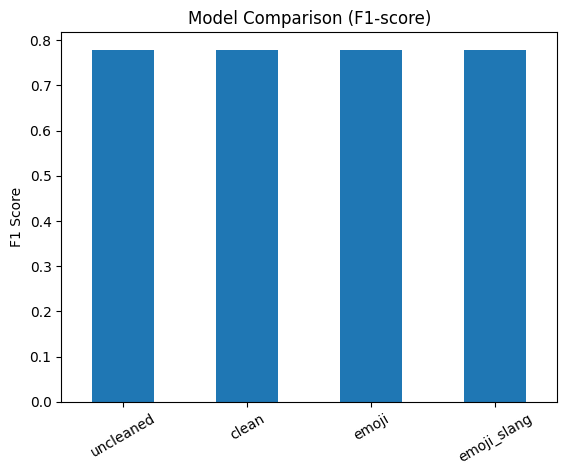

In [ ]:
import matplotlib.pyplot as plt

df_results["f1-score"].plot(kind="bar", title="Model Comparison (F1-score)")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()

## Confusion Matrix

uncleaned model

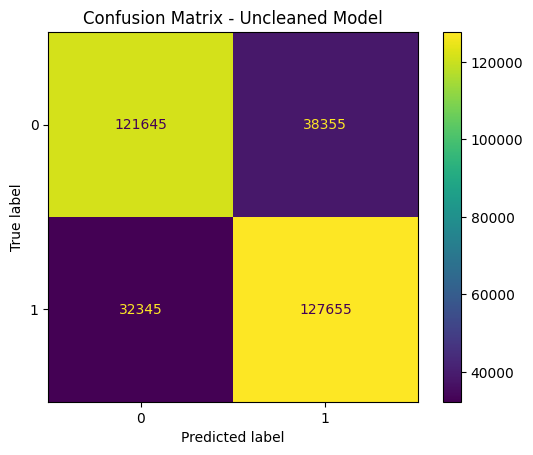

In [ ]:
y_pred_uncleaned = model_uncleaned.predict(X_test_raw)

cm = confusion_matrix(y_test, y_pred_uncleaned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Uncleaned Model")
plt.show()

Slang cleaned

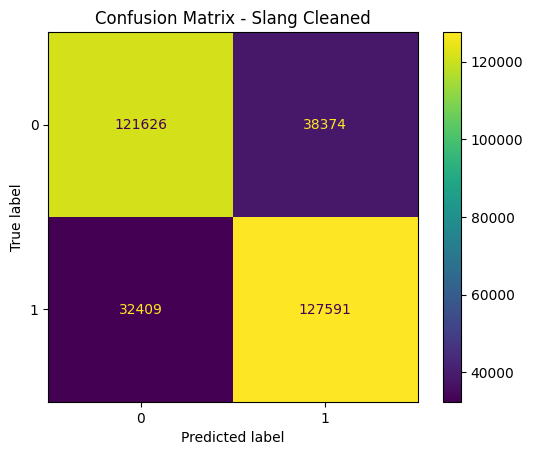

In [ ]:
y_pred_clean = model_slang_cleaned.predict(X_test_clean)
cm_clean = confusion_matrix(y_test, y_pred_clean)

ConfusionMatrixDisplay(confusion_matrix=cm_clean).plot()
plt.title("Confusion Matrix - Slang Cleaned")
plt.show()

Emoji cleaned

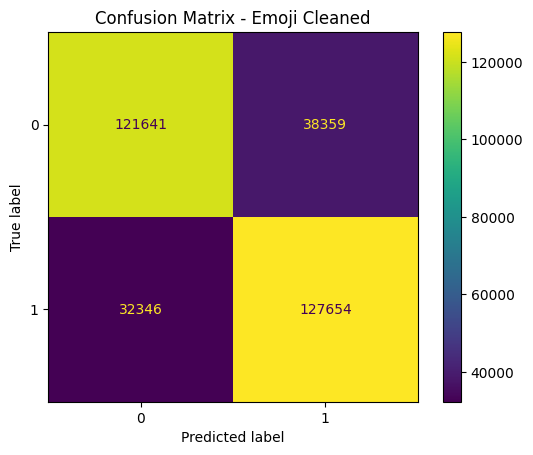

In [ ]:
y_pred_emoji = model_emoji_cleaned.predict(X_test_emoji)
cm_emoji = confusion_matrix(y_test, y_pred_emoji)

ConfusionMatrixDisplay(confusion_matrix=cm_emoji).plot()
plt.title("Confusion Matrix - Emoji Cleaned")
plt.show()

Slang + Emoji

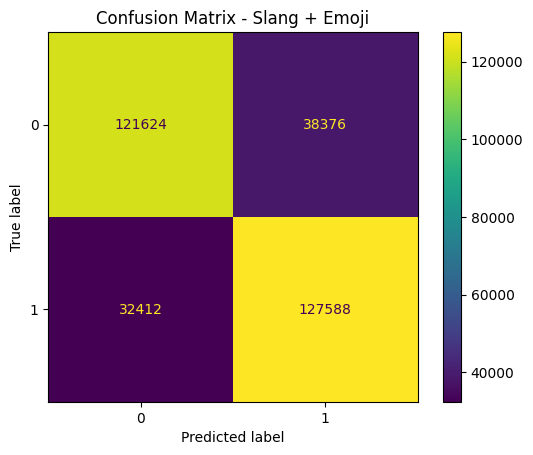

In [ ]:
y_pred_emoji_slang = model_slang_emoji_cleaned.predict(X_test_emoji_slang)
cm_emoji_slang = confusion_matrix(y_test, y_pred_emoji_slang)

ConfusionMatrixDisplay(confusion_matrix=cm_emoji_slang).plot()
plt.title("Confusion Matrix - Slang + Emoji")
plt.show()

Class Distribution (Dataset balance)

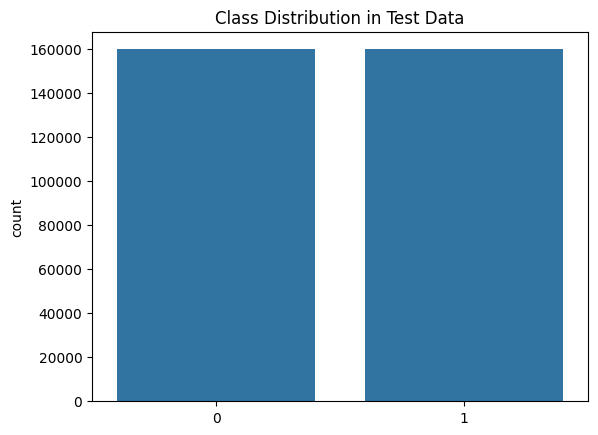

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_test)
plt.title("Class Distribution in Test Data")
plt.show()

ROC Curve

uncleaned model

In [ ]:
from sklearn.metrics import roc_curve, auc

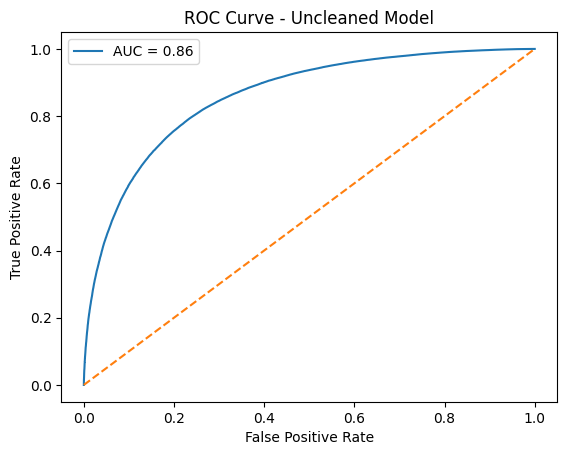

In [ ]:
# probability predictions (uncleaned model)
y_prob = model_uncleaned.predict_proba(X_test_raw)[:, 1]

# ROC curve values
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')

plt.title("ROC Curve - Uncleaned Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Slang cleaned

Prediction Distribution

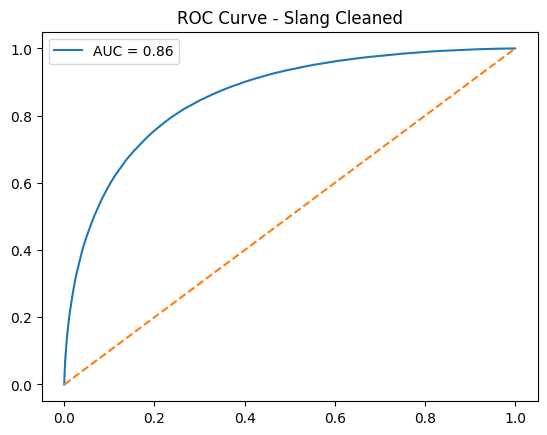

In [ ]:
y_prob = model_slang_cleaned.predict_proba(X_test_clean)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve - Slang Cleaned")
plt.legend()
plt.show()

Emoji cleaned

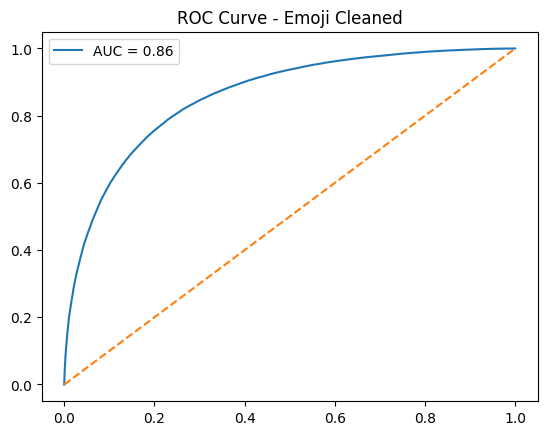

In [ ]:
y_prob = model_emoji_cleaned.predict_proba(X_test_emoji)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve - Emoji Cleaned")
plt.legend()
plt.show()

Slang + Emoji

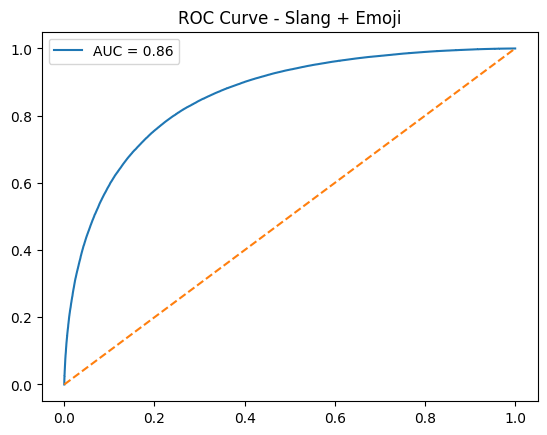

In [ ]:
y_prob = model_slang_emoji_cleaned.predict_proba(X_test_emoji_slang)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve - Slang + Emoji")
plt.legend()
plt.show()

## SIDE-BY-SIDE PLOT (ALL MODELS)

In [ ]:
y_pred_uncleaned = model_uncleaned.predict(X_test_raw)
y_pred_clean = model_slang_cleaned.predict(X_test_clean)
y_pred_emoji = model_emoji_cleaned.predict(X_test_emoji)
y_pred_emoji_slang = model_slang_emoji_cleaned.predict(X_test_emoji_slang)

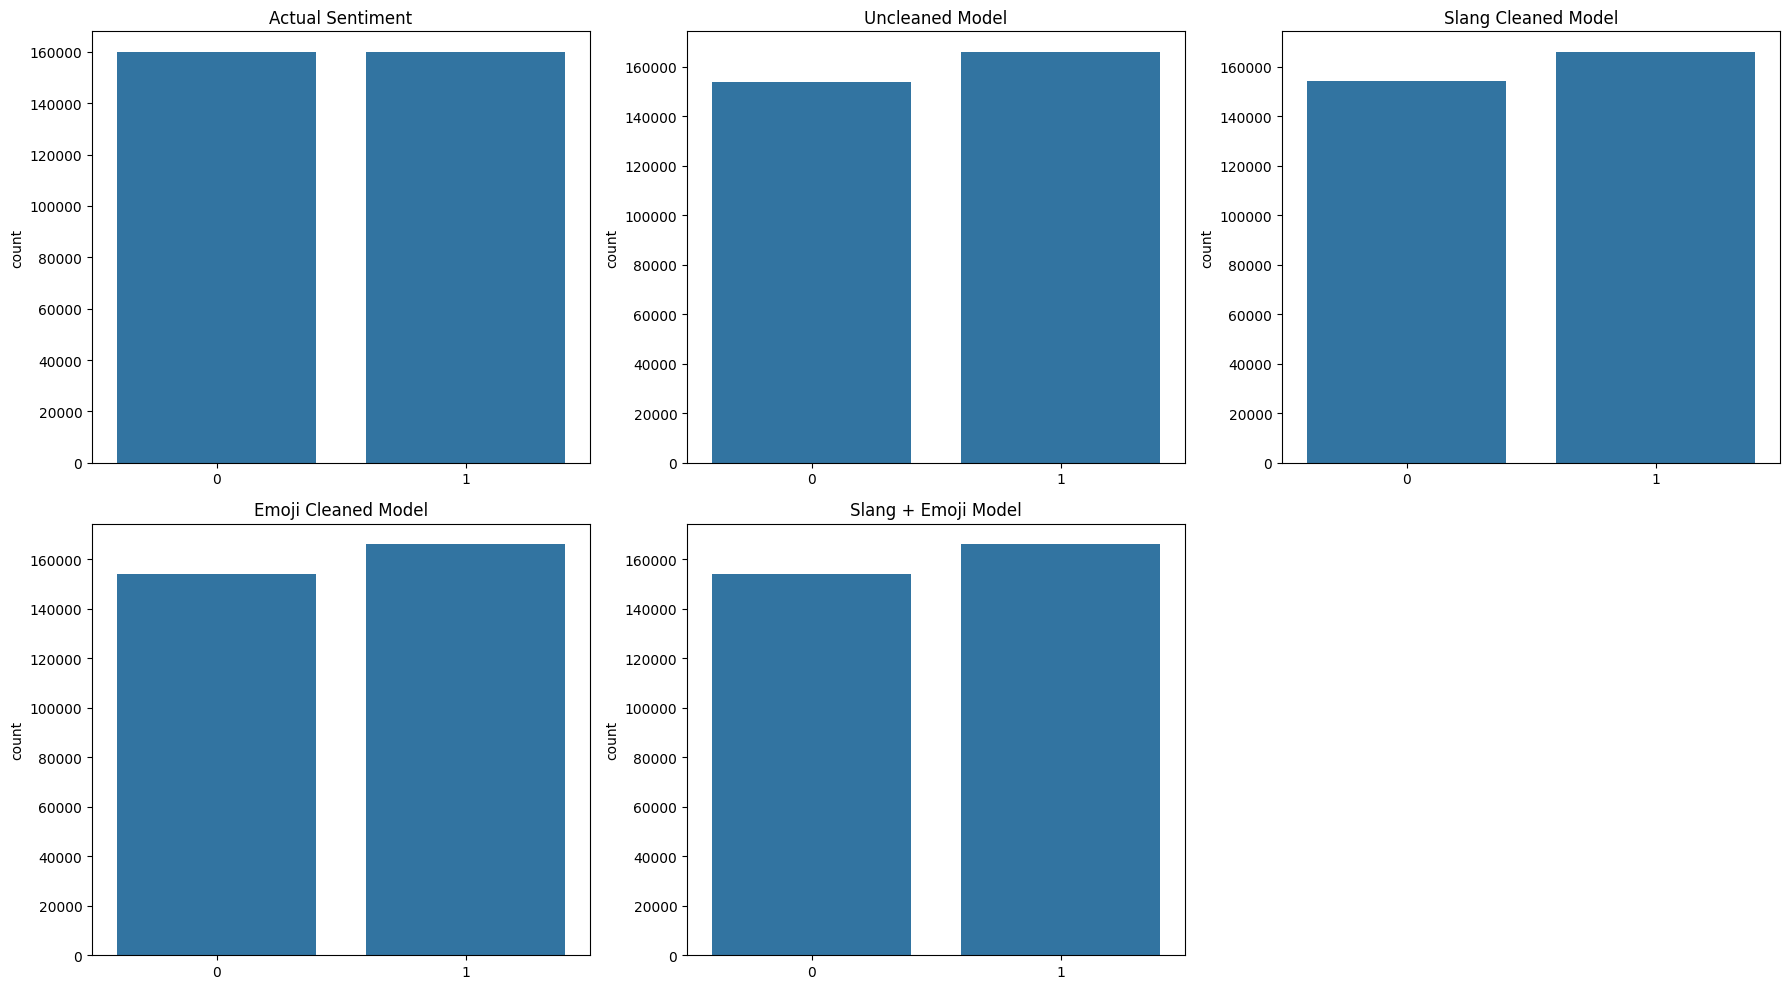

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(x=y_test, ax=axes[0, 0])
axes[0, 0].set_title("Actual Sentiment")
axes[0, 0].set_xlabel("")

sns.countplot(x=y_pred_uncleaned, ax=axes[0, 1])
axes[0, 1].set_title("Uncleaned Model")
axes[0, 1].set_xlabel("")

sns.countplot(x=y_pred_clean, ax=axes[0, 2])
axes[0, 2].set_title("Slang Cleaned Model")
axes[0, 2].set_xlabel("")

sns.countplot(x=y_pred_emoji, ax=axes[1, 0])
axes[1, 0].set_title("Emoji Cleaned Model")

sns.countplot(x=y_pred_emoji_slang, ax=axes[1, 1])
axes[1, 1].set_title("Slang + Emoji Model")


fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

FINAL CONCLUSION FIGURE

Convert to percentage distributions

In [ ]:
def get_percent(data):
    values, counts = np.unique(data, return_counts=True)
    percent = counts / counts.sum() * 100
    return {values[i]: percent[i] for i in range(len(values))}

In [ ]:
actual = get_percent(y_test)
uncleaned = get_percent(y_pred_uncleaned)
clean = get_percent(y_pred_clean)
emoji = get_percent(y_pred_emoji)
emoji_slang = get_percent(y_pred_emoji_slang)

Prepare plotting data

In [ ]:
labels = sorted(actual.keys())  # usually [0, 1]

models = {
    "Actual": actual,
    "Uncleaned": uncleaned,
    "Slang Cleaned": clean,
    "Emoji Cleaned": emoji,
    "Slang + Emoji": emoji_slang
}

Create final comparison figure

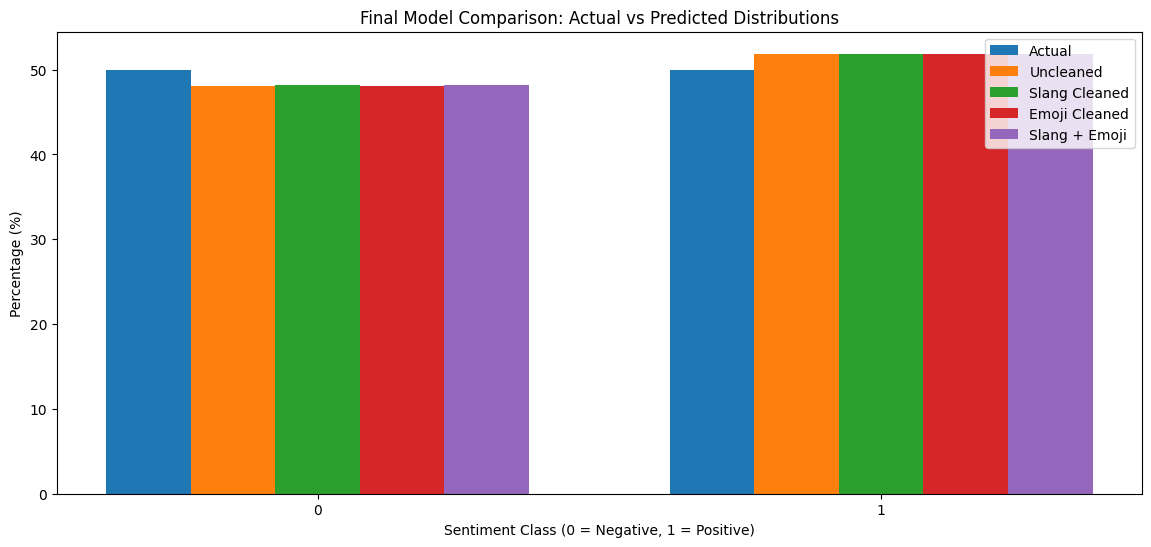

In [ ]:
x = np.arange(len(labels))
width = 0.15

plt.figure(figsize=(14, 6))

for i, (name, values) in enumerate(models.items()):
    y = [values.get(label, 0) for label in labels]
    plt.bar(x + i * width, y, width, label=name)

plt.xlabel("Sentiment Class (0 = Negative, 1 = Positive)")
plt.ylabel("Percentage (%)")
plt.title("Final Model Comparison: Actual vs Predicted Distributions")
plt.xticks(x + width*2, labels)
plt.legend()
plt.show()

# Sentiment Analysis using NLP Preprocessing Techniques

## 📌 Abstract
This project investigates the impact of different NLP preprocessing techniques on sentiment classification performance. Using the **Sentiment140 dataset (Kaggle)**, a binary classification task was performed to predict **positive (1)** and **negative (0)** sentiments from Twitter data. The study compares multiple preprocessing strategies including raw text, slang normalization, emoji normalization, and combined slang + emoji normalization. A Logistic Regression model with TF-IDF features is used as the baseline classifier, and performance is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

---

## 📊 Dataset Description
- **Source:** Kaggle Sentiment140 Dataset  
- **Type:** Twitter sentiment dataset  
- **Task:** Binary classification  
- **Classes:**
  - `0 → Negative`
  - `1 → Positive`  
- **Total Samples:** Large-scale labeled tweets  

---

## ⚙️ Methodology

### 1. Data Preprocessing
Four different preprocessing strategies were applied:

- **Uncleaned Text:** Raw tweets without modification  
- **Slang Normalized:** Slang terms converted into standard English  
- **Emoji Normalized:** Emojis converted into textual meaning  
- **Slang + Emoji Normalized:** Combination of both preprocessing techniques  

---

### 2. Feature Extraction
Text data was transformed using:

- **TF-IDF Vectorization**

This converts textual data into numerical feature vectors suitable for machine learning models.

---

### 3. Model Used
- **Algorithm:** Logistic Regression  
- **Solver:** `saga`  
- **Max Iterations:** 1000  
- **Reason:** Efficient and strong baseline for high-dimensional sparse text data  

---

### 4. Evaluation Metrics
The following metrics were used for evaluation:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC  

---

## 📈 Experimental Results

### 🔹 Accuracy Comparison

| Model | Train Accuracy | Test Accuracy |
|------|---------------|--------------|
| Uncleaned | 0.8101 | 0.7791 |
| Slang Cleaned | 0.8099 | 0.7788 |
| Emoji Cleaned | 0.8101 | 0.7790 |
| Slang + Emoji Cleaned | 0.8099 | 0.7788 |

---

### 🔹 Classification Report (Test Set)

| Model | Precision | Recall | F1-score | Accuracy |
|------|----------|--------|----------|----------|
| Uncleaned | 0.7795 | 0.7791 | 0.7790 | 0.7791 |
| Slang Cleaned | 0.7792 | 0.7788 | 0.7787 | 0.7788 |
| Emoji Cleaned | 0.7794 | 0.7790 | 0.7790 | 0.7790 |
| Slang + Emoji Cleaned | 0.7792 | 0.7788 | 0.7787 | 0.7788 |

---

### 🔹 ROC-AUC Score
- **ROC-AUC (All Models): 0.86**

This indicates a strong ability of the models to distinguish between positive and negative sentiment classes.

---

## 🔍 Key Findings

- All preprocessing methods produced **very similar performance**
- No significant improvement was observed from slang or emoji normalization
- TF-IDF representation proved to be **highly effective for sentiment classification**
- Logistic Regression performed as a **strong baseline model**
- Dataset size and structure had more influence than preprocessing variations

---

## 🔍 Analysis of Preprocessing Impact (Slang & Emoji Normalization)

Although emojis and slang expressions are known to carry strong sentiment information, the experimental results showed **minimal performance differences** between the uncleaned and normalized datasets. This observation can be explained by several key factors:

### 1. Effectiveness of TF-IDF Representation
TF-IDF is highly effective at capturing important sentiment-bearing words such as *“good”*, *“bad”*, *“love”*, and *“hate”*. These words dominate sentiment classification, reducing the relative impact of additional preprocessing.

---

### 2. Redundancy of Emoji Normalization
When emojis are converted into textual representations (e.g., 😍 → *“love”*, 😡 → *“angry”*), they often map to words that are already present in the dataset. As a result, normalization does not introduce significant new information.

---

### 3. Slang is Learned from Data Distribution
In a large dataset like Sentiment140, commonly used slang terms (e.g., *“lit”*, *“lol”*, *“omg”*) appear frequently enough for the model to learn their sentiment associations directly. Therefore, converting slang into standard words does not substantially change the feature space.

---

### 4. Impact of Large Dataset Size
The Sentiment140 dataset contains a large number of samples (~1.6 million tweets), allowing the model to learn robust statistical patterns. In such cases, preprocessing techniques have a reduced marginal effect compared to smaller datasets.

---

### 5. Model Limitations
Logistic Regression with TF-IDF is a **linear, bag-of-words-based model**, which:
- Does not capture deep contextual meaning
- Cannot fully utilize nuanced semantic transformations
- Treats words independently without understanding relationships

As a result, improvements from semantic normalization are limited.

---

### 📌 Key Insight

> While slang and emoji normalization are conceptually meaningful preprocessing steps, their practical impact depends on the model and dataset. In this study, the combination of a large dataset and TF-IDF features already captures sufficient sentiment information, making additional normalization techniques largely redundant.

---

### 🚀 Implication for Future Work

The impact of such preprocessing techniques may become more significant when:
- Using **smaller or noisier datasets**
- Applying **deep learning models (e.g., LSTM, BERT)** that capture context
- Working with **multilingual or highly informal text data**

This highlights the importance of aligning preprocessing strategies with the chosen model and dataset characteristics.


---
## 🧠 Conclusion

This study demonstrates that different NLP preprocessing techniques have minimal impact on model performance for large-scale sentiment analysis tasks using TF-IDF and Logistic Regression. All models achieved nearly identical results, with test accuracy around **77.8%-77.9%** and ROC-AUC of **0.86**.

The findings suggest that for large datasets like Sentiment140, **simple feature extraction methods combined with linear models are sufficient to achieve strong performance**, and additional preprocessing does not significantly improve results.

---

## 🚀 Future Work

- Implement deep learning models (LSTM, GRU, BERT)  
- Use contextual embeddings (Word2Vec, FastText, Transformers)  
- Perform error analysis on misclassified samples  
- Explore advanced feature engineering techniques  
- Address class imbalance and threshold tuning  

---

## 📌 Final Remark
This project provides a complete NLP pipeline for sentiment analysis and highlights the real-world effectiveness of preprocessing techniques in text classification tasks.

In [132]:
!git config --global user.name "aayush-12321"
!git config --global user.email "aayushparajuli23@gmail.com"

In [150]:
!cat .gitignore

# Data files
data/
datasets/
*.csv
*.xlsx
*.json

# Model files (optional, keep only if needed)
*.pkl
*.joblib
*.h5
*.pt

# Python cache
__pycache__/
*.pyc

# Jupyter checkpoints
.ipynb_checkpoints/

# OS files
.DS_Store
